# Module 4 — SIFT Feature Extraction & Database Construction

**Project:** Face Recognition Pipeline  
**Dataset:** AT&T Database of Faces (ORL Face Database)  
**Goal:** Extract SIFT descriptors from all face images and save a feature database for use in later modules.

---

## Dataset Overview

| Property | Value |
|---|---|
| Source | Kaggle — `kasikrit/att-database-of-faces` |
| Subjects | 40 persons |
| Images per subject | 10 |
| Total images | 400 |
| Format | `.pgm` (grayscale) |
| Resolution | 112 × 92 pixels |

---

## Module Scope

**Input:** Raw face images organized by subject folder (`s1/`, `s2/`, ..., `s40/`)  
**Output:** Serialized feature database file (`sift_feature_database.pkl`)

> This module does **not** perform matching or classification.  
> It focuses solely on feature extraction, organization, and storage.

---
## Step 1 — Install Required Libraries

In [2]:
# Run this cell only once (e.g., on Google Colab or a fresh environment)
!pip install kagglehub opencv-python matplotlib --quiet


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## Step 2 — Import Libraries

In [3]:
import os
import cv2
import pickle
import kagglehub
import matplotlib.pyplot as plt

print("All libraries imported successfully.")
print(f"OpenCV version: {cv2.__version__}")

c:\Users\dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All libraries imported successfully.
OpenCV version: 4.12.0


---
## Step 3 — Download the Dataset

We use `kagglehub` to automatically download the AT&T face dataset.  
No API key or manual download is required.

In [4]:
# Download the AT&T Faces dataset from Kaggle
dataset_path = kagglehub.dataset_download("kasikrit/att-database-of-faces")

print("Dataset downloaded successfully.")
print(f"Path: {dataset_path}")

100%|██████████| 3.61M/3.61M [00:07<00:00, 514kB/s]

Extracting files...


Dataset downloaded successfully.
Path: C:\Users\dell\.cache\kagglehub\datasets\kasikrit\att-database-of-faces\versions\2


---
## Step 4 — Explore the Dataset Structure

In [5]:
# List all subject folders in the dataset
subjects = sorted(
    [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]
)

print(f"Total subjects found : {len(subjects)}")
print(f"Subject folders      : {subjects[:5]} ... {subjects[-3:]}")

# Show number of images per subject (as a sanity check)
sample_subject = subjects[0]
sample_images = os.listdir(os.path.join(dataset_path, sample_subject))
print(f"Images per subject   : {len(sample_images)} (example from '{sample_subject}')")

Total subjects found : 40
Subject folders      : ['s1', 's10', 's11', 's12', 's13'] ... ['s7', 's8', 's9']
Images per subject   : 10 (example from 's1')


---
## Step 5 — Visualize Sample Images

We display a few sample images to confirm the dataset is loaded correctly before processing.

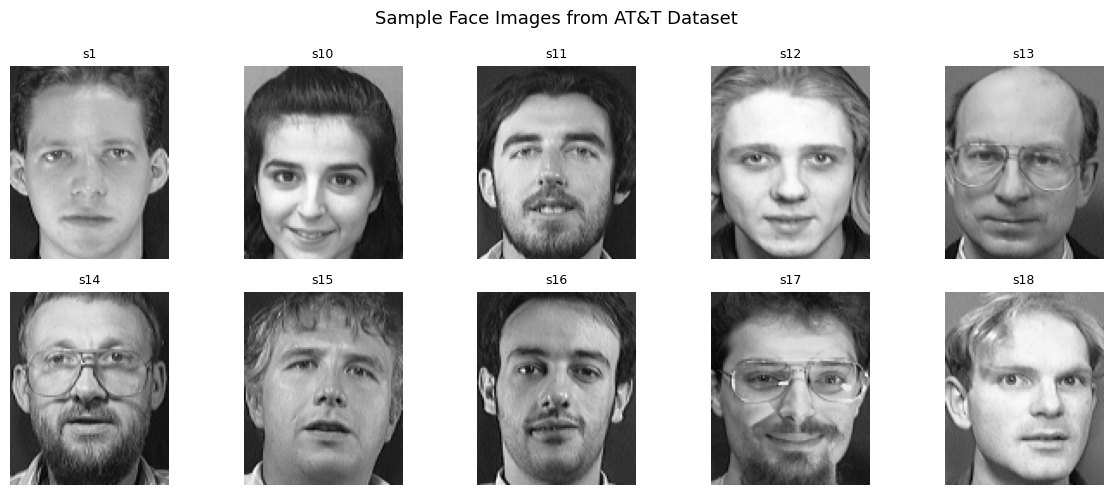

Image size: 112 × 92 pixels


In [6]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Face Images from AT&T Dataset", fontsize=13)

for i, subject in enumerate(subjects[:10]):
    img_path = os.path.join(dataset_path, subject, "1.pgm")
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    ax = axes[i // 5][i % 5]
    ax.imshow(img, cmap="gray")
    ax.set_title(subject, fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Image size: {img.shape[0]} × {img.shape[1]} pixels")

---
## Step 6 — Initialize SIFT Detector

**SIFT (Scale-Invariant Feature Transform)** detects and describes local features in images.  
It is robust to changes in scale, rotation, and illumination — ideal for face recognition tasks.

In [7]:
sift = cv2.SIFT_create()

print("SIFT detector initialized.")
print("Each image will be described by a set of 128-dimensional keypoint descriptors.")

SIFT detector initialized.
Each image will be described by a set of 128-dimensional keypoint descriptors.


---
## Step 7 — Visualize SIFT Keypoints on a Sample Image

Before running full extraction, we visualize the keypoints detected on one image.

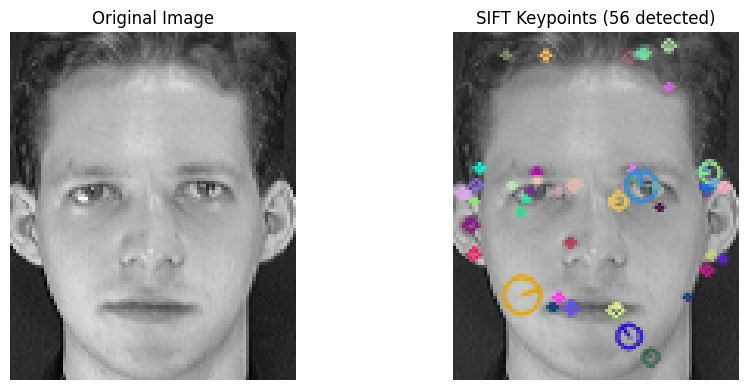

Keypoints detected  : 56
Descriptor shape    : (56, 128)  → (56 keypoints × 128 dimensions)


In [8]:
sample_path = os.path.join(dataset_path, "s1", "1.pgm")
sample_img  = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

# Detect keypoints
keypoints, descriptors = sift.detectAndCompute(sample_img, None)

# Draw keypoints on the image
img_with_kp = cv2.drawKeypoints(
    sample_img, keypoints, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(img_with_kp)
axes[1].set_title(f"SIFT Keypoints ({len(keypoints)} detected)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print(f"Keypoints detected  : {len(keypoints)}")
print(f"Descriptor shape    : {descriptors.shape}  → ({len(keypoints)} keypoints × 128 dimensions)")

---
## Step 8 — Extract SIFT Features for All Images

We iterate over every subject and every image, extract SIFT descriptors, and store them in a dictionary.

**Structure of `feature_database`:**
```
{
  "s1": [array(n1×128), array(n2×128), ...],   # one array per image
  "s2": [...],
  ...
  "s40": [...]
}
```

In [9]:
feature_database = {}
skipped_images   = 0

for subject in subjects:
    subject_path     = os.path.join(dataset_path, subject)
    descriptors_list = []

    for image_name in sorted(os.listdir(subject_path)):
        image_path  = os.path.join(subject_path, image_name)
        image       = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            skipped_images += 1
            continue

        keypoints, descriptors = sift.detectAndCompute(image, None)

        if descriptors is not None:
            descriptors_list.append(descriptors)
        else:
            # No keypoints found — skip this image
            skipped_images += 1

    feature_database[subject] = descriptors_list
    print(f"{subject}: {len(descriptors_list)} images processed")

print(f"\nExtraction complete.")
print(f"Total subjects      : {len(feature_database)}")
print(f"Skipped images      : {skipped_images}")

s1: 10 images processed
s10: 10 images processed
s11: 10 images processed
s12: 10 images processed
s13: 10 images processed
s14: 10 images processed
s15: 10 images processed
s16: 10 images processed
s17: 10 images processed
s18: 10 images processed
s19: 10 images processed
s2: 10 images processed
s20: 10 images processed
s21: 10 images processed
s22: 10 images processed
s23: 10 images processed
s24: 10 images processed
s25: 10 images processed
s26: 10 images processed
s27: 10 images processed
s28: 10 images processed
s29: 10 images processed
s3: 10 images processed
s30: 10 images processed
s31: 10 images processed
s32: 10 images processed
s33: 10 images processed
s34: 10 images processed
s35: 10 images processed
s36: 10 images processed
s37: 10 images processed
s38: 10 images processed
s39: 10 images processed
s4: 10 images processed
s40: 10 images processed
s5: 10 images processed
s6: 10 images processed
s7: 10 images processed
s8: 10 images processed
s9: 10 images processed

Extracti

---
## Step 9 — Save Feature Database to Disk

We serialize the database using Python's `pickle` module.  
This preserves NumPy arrays and is efficient for academic experiments.

The saved file (`sift_feature_database.pkl`) is the **official output of Module 4**  
and will be used directly by the next module for matching and classification.

In [10]:
output_file = "sift_feature_database.pkl"

with open(output_file, "wb") as f:
    pickle.dump(feature_database, f)

file_size_kb = os.path.getsize(output_file) / 1024

print(f"Feature database saved : {output_file}")
print(f"File size              : {file_size_kb:.1f} KB")

Feature database saved : sift_feature_database.pkl
File size              : 13606.7 KB


---
## Step 10 — Verify Saved Database

In [11]:
# Reload and inspect the saved database
with open(output_file, "rb") as f:
    db = pickle.load(f)

first_subject = list(db.keys())[0]
first_desc    = db[first_subject][0]

print("Database verification")
print("-" * 35)
print(f"Total subjects stored   : {len(db)}")
print(f"Example subject         : {first_subject}")
print(f"Images for this subject : {len(db[first_subject])}")
print(f"Descriptor shape        : {first_desc.shape}")
print(f"Descriptor dtype        : {first_desc.dtype}")
print("-" * 35)
print("Database is valid and ready for use in the next module.")

Database verification
-----------------------------------
Total subjects stored   : 40
Example subject         : s1
Images for this subject : 10
Descriptor shape        : (56, 128)
Descriptor dtype        : float32
-----------------------------------
Database is valid and ready for use in the next module.


---
## Summary

| Step | Task | Status |
|---|---|---|
| 1–2 | Install and import libraries | Done |
| 3 | Download AT&T dataset via `kagglehub` | Done |
| 4–5 | Explore and visualize dataset | Done |
| 6–7 | Initialize SIFT and visualize keypoints | Done |
| 8 | Extract SIFT descriptors for all 400 images | Done |
| 9 | Save feature database (`sift_feature_database.pkl`) | Done |
| 10 | Verify saved database | Done |

---

**Handoff note for Module 5:**

> This module extracted SIFT descriptors from the AT&T face dataset and organized them into a serialized feature database. Each key in the dictionary is a subject ID (e.g., `"s1"`), and the value is a list of NumPy arrays — one per image — each of shape `(N, 128)` where N is the number of keypoints detected in that image. Load the file with `pickle.load()` to begin matching or classification.